# Model Building: NLP Intent Classifier

This notebook trains and evaluates the second machine learning model used in
the Campus Spatial Decision Support System: an **intent classifier** that
reads a natural language query (e.g. *"Which computers in Block C can't run
Windows 11?"*) and classifies it into one of six intent categories, so the
system knows how to route and answer it.

**Pipeline:** Data Loading -> TF-IDF Feature Extraction -> Train/Test Split ->
Model Training -> Evaluation -> Visualization -> Adversarial Stress Test ->
Model Saving

This notebook deliberately includes both an in-distribution evaluation AND a
hand-written adversarial evaluation, because the gap between the two is this
project's most important honest finding about the NLP component (see Section
9 below).


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Data Loading

We load the 10,000-query NLP corpus, built via LLM-assisted generation and
structurally validated against the system's known intent and entity
vocabularies (see `evaluation/EVALUATION_SUMMARY.md` for the full dataset
construction methodology).


In [2]:
DATA_PATH = Path.cwd().parent / "data" / "nlp_query_dataset_10000.csv"
df = pd.read_csv(DATA_PATH)

print(f"Total queries: {len(df)}")
print(f"Intent categories: {df['intent'].nunique()}")
df.head()


Total queries: 10000
Intent categories: 6


,query_id,text,intent,location,target_os,software,condition
0,q00001,List machines in Lab 1 that meet Fedora 42 req...,os_compatibility_check,Lab 1,Fedora 42,NaN,NaN
1,q00002,Which systems support VMware Workstation in La...,software_compatibility_check,Lab 2,NaN,VMware Workstation,NaN
2,q00003,Best operating system for AI Lab?,os_recommendation,AI Lab,Debian 13,NaN,NaN
3,q00004,Can computers in Block A run Blender?,software_compatibility_check,Block A,NaN,Blender,NaN
4,q00005,Check MATLAB compatibility for Programming Lab.,software_compatibility_check,Programming Lab,NaN,MATLAB,NaN


## 2. Class Distribution

How balanced are the six intent categories?

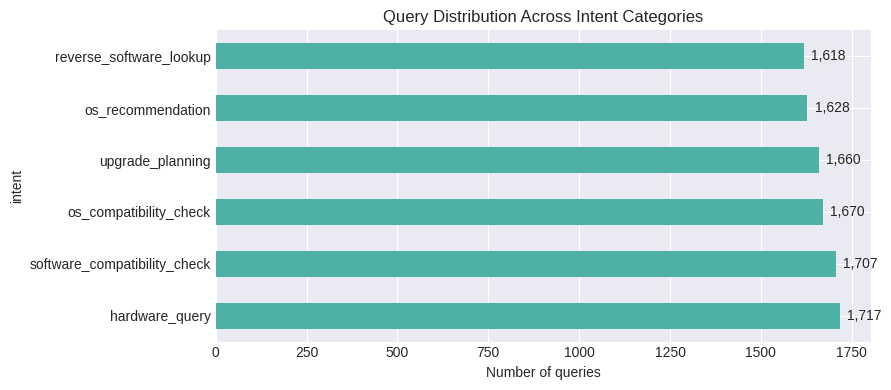

Most common: hardware_query (1717 queries)
Least common: reverse_software_lookup (1618 queries)
Balance ratio: 0.94 (1.0 = perfectly balanced)


In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
counts = df['intent'].value_counts()
counts.plot(kind='barh', ax=ax, color='#4fb0a5')
ax.set_xlabel('Number of queries')
ax.set_title('Query Distribution Across Intent Categories')
for i, v in enumerate(counts.values):
    ax.text(v + 20, i, f'{v:,}', va='center')
plt.tight_layout()
plt.savefig('nlp_class_distribution.png', dpi=120)
plt.show()

print(f"Most common: {counts.idxmax()} ({counts.max()} queries)")
print(f"Least common: {counts.idxmin()} ({counts.min()} queries)")
print(f"Balance ratio: {counts.min()/counts.max():.2f} (1.0 = perfectly balanced)")


## 3. Train/Test Split

We hold out 20% of the corpus, stratified by intent so each split preserves
the same category proportions.


In [4]:
X = df['text']
y = df['intent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} queries")
print(f"Test set:     {len(X_test)} queries")


Training set: 8000 queries
Test set:     2000 queries


## 4. Feature Extraction + Model Training

We use TF-IDF (unigrams + bigrams) with a Logistic Regression classifier.
This is a deliberately lightweight choice: for a single-domain, six-class
problem like this one, a large transformer model would add cost without
demonstrated benefit over a simple, fast, interpretable baseline.


In [5]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=5000, stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000, C=5.0, class_weight="balanced")),
])

pipeline.fit(X_train, y_train)
print("Model trained.")
print(f"Vocabulary size: {len(pipeline.named_steps['tfidf'].vocabulary_)}")


Model trained.
Vocabulary size: 398


## 5. In-Distribution Evaluation

How well does the model do on held-out queries drawn from the same synthetic corpus?

In [6]:
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Held-out test accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred))


Held-out test accuracy: 1.0000

                              precision    recall  f1-score   support

              hardware_query       1.00      1.00      1.00       343
      os_compatibility_check       1.00      1.00      1.00       334
           os_recommendation       1.00      1.00      1.00       326
     reverse_software_lookup       1.00      1.00      1.00       324
software_compatibility_check       1.00      1.00      1.00       341
            upgrade_planning       1.00      1.00      1.00       332

                    accuracy                           1.00      2000
                   macro avg       1.00      1.00      1.00      2000
                weighted avg       1.00      1.00      1.00      2000



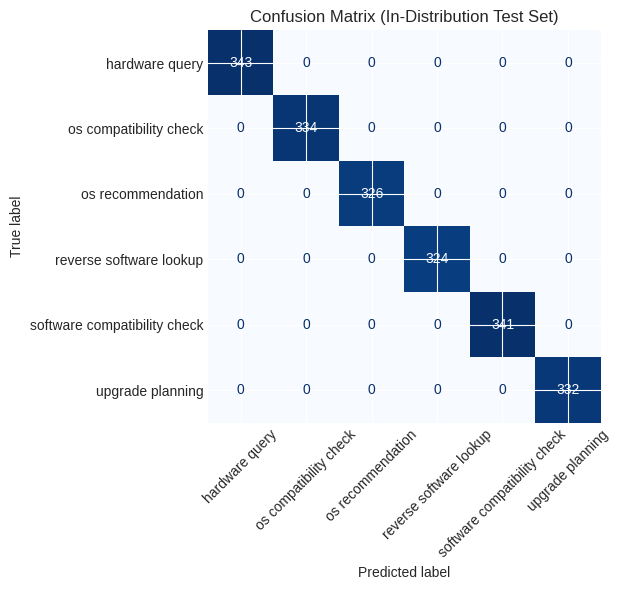

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[l.replace('_', ' ') for l in labels])
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title('Confusion Matrix (In-Distribution Test Set)')
plt.tight_layout()
plt.savefig('nlp_confusion_matrix.png', dpi=120)
plt.show()


**Important interpretation note**: near-perfect accuracy here is expected but
should NOT be read as representative of real-world performance. It reflects
that the synthetic query corpus was generated from templates that are highly
separable by simple keyword/phrasing cues -- not that the model has learned
robust, general language understanding. Section 9 below tests this directly.


## 6-8. (Reserved)

Sections 6-8 in the companion compatibility-model notebook cover feature
importance and model saving; for a linear TF-IDF model, the most informative
equivalent is inspecting the highest-weighted terms per class, shown next.


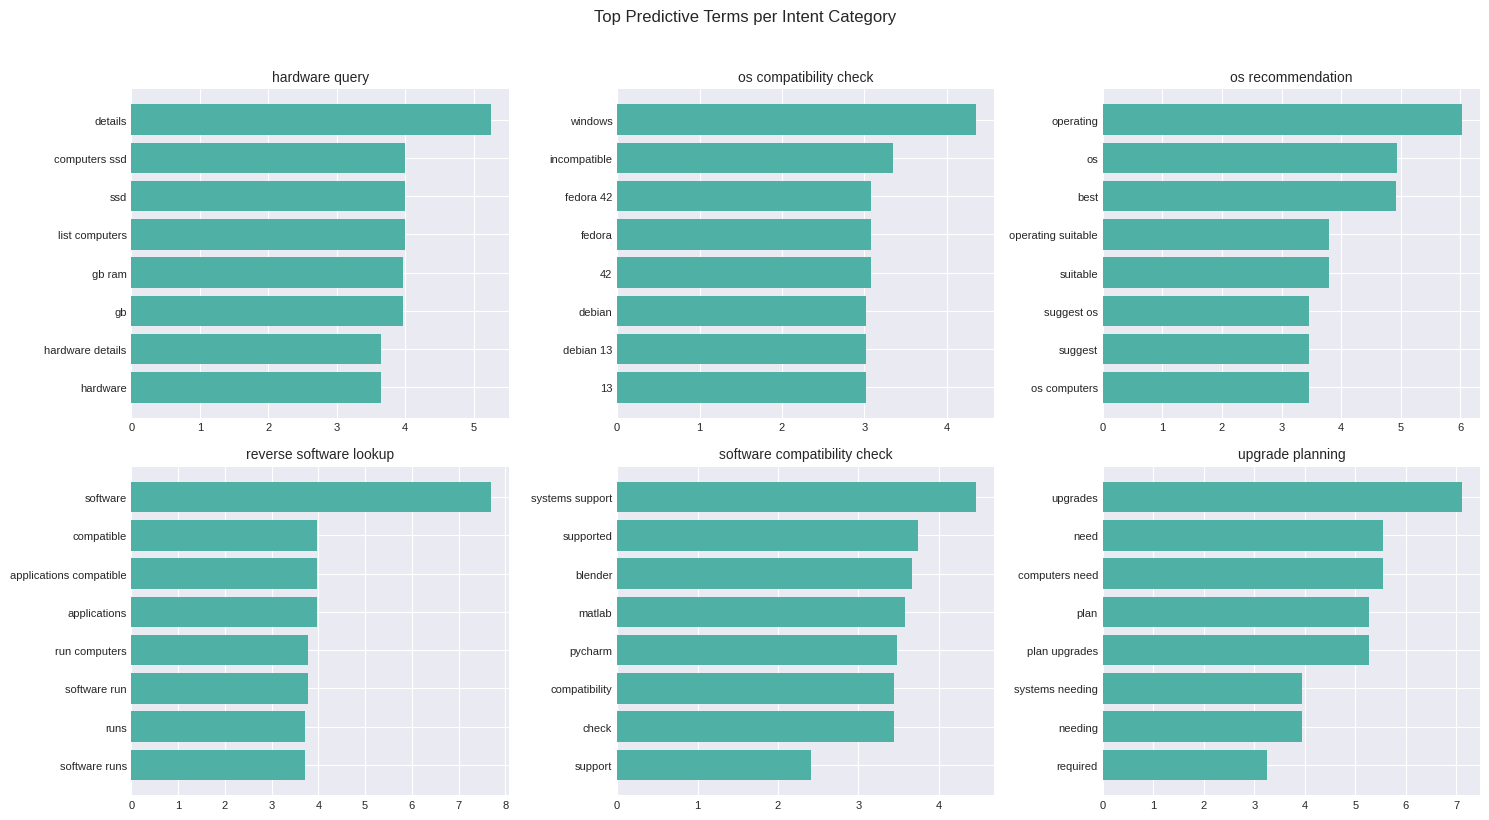

In [8]:
tfidf = pipeline.named_steps['tfidf']
clf = pipeline.named_steps['clf']
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, intent_class in enumerate(clf.classes_):
    top_idx = np.argsort(clf.coef_[i])[-8:]
    top_terms = feature_names[top_idx]
    top_weights = clf.coef_[i][top_idx]
    axes[i].barh(top_terms, top_weights, color='#4fb0a5')
    axes[i].set_title(intent_class.replace('_', ' '), fontsize=10)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Top Predictive Terms per Intent Category', y=1.02)
plt.tight_layout()
plt.savefig('nlp_top_terms.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Adversarial Stress Test (The Important Part)

The evaluation above uses queries from the *same synthetic generation process*
as the training data. To honestly assess generalization, we now test the
model against 40 queries written by hand -- deliberately varied, informal,
indirect, and with minimal keyword overlap with the training templates. This
is the single most important evaluation in this notebook.


In [9]:
STRESS_TEST_QUERIES = [
    ("Can the machines in Block A even handle Windows 11?", "os_compatibility_check"),
    ("I don't think the Network Lab PCs support Win11, can you check?", "os_compatibility_check"),
    ("Whats the deal with Block B and Windows 10 compatibility", "os_compatibility_check"),
    ("Is there any chance the AI Lab computers run Fedora 42 ok?", "os_compatibility_check"),
    ("please tell me if programming lab systems r compatible w ubuntu 24.04", "os_compatibility_check"),
    ("Block C machines -- Windows 11 yes or no", "os_compatibility_check"),
    ("so which os is actually best for the library computers", "os_recommendation"),
    ("if you had to pick one OS for CAD Lab what would it be", "os_recommendation"),
    ("whats the ideal operating system given the specs in block d", "os_recommendation"),
    ("Language Lab needs a new OS, suggestions?", "os_recommendation"),
    ("what should we install on the research lab machines", "os_recommendation"),
    ("out of curiosity what os would you recommend for admin", "os_recommendation"),
    ("these block a computers are ancient, what needs replacing", "upgrade_planning"),
    ("figure out which machines in the network lab are due for an upgrade", "upgrade_planning"),
    ("we've got budget this year, what should we prioritize upgrading in block c", "upgrade_planning"),
    ("anything ancient still running in the library that needs attention", "upgrade_planning"),
    ("time to replace old hardware -- where should we start in block b", "upgrade_planning"),
    ("does the programming lab even have enough ram for anything modern", "hardware_query"),
    ("how many machines in block d have ssds", "hardware_query"),
    ("give me the cpu breakdown for the ai lab", "hardware_query"),
    ("whats the average ram across the research lab computers", "hardware_query"),
    ("do any admin block machines have tpm chips", "hardware_query"),
    ("can blender actually run on the cad lab machines", "software_compatibility_check"),
    ("checking if photoshop would work on block c hardware", "software_compatibility_check"),
    ("will the network lab pcs handle wireshark fine", "software_compatibility_check"),
    ("thinking about installing matlab in the research lab, feasible?", "software_compatibility_check"),
    ("does anaconda run ok on the ai lab systems", "software_compatibility_check"),
    ("not sure if the library computers could run libreoffice smoothly", "software_compatibility_check"),
    ("what could we actually install on the current programming lab setup", "reverse_software_lookup"),
    ("given the hardware in block a, what software options do we have", "reverse_software_lookup"),
    ("list stuff compatible with whatever is running in the language lab", "reverse_software_lookup"),
    ("what can these old admin machines actually still run", "reverse_software_lookup"),
    ("show compatible apps for block d hardware", "reverse_software_lookup"),
    ("upgrade or os change, which fixes block c faster", "upgrade_planning"),
    ("running old software on new labs, what os makes sense for that in the cad lab", "os_recommendation"),
    ("lab 2 -- worth upgrading or just switch os?", "upgrade_planning"),
    ("what does the research lab even have installed right now", "hardware_query"),
    ("any machine anywhere that can run autocad without upgrades", "reverse_software_lookup"),
    ("give me a straight answer: win11 on block b, yes or no", "os_compatibility_check"),
    ("honestly just tell me the best linux distro for ai lab", "os_recommendation"),
]

stress_df = pd.DataFrame(STRESS_TEST_QUERIES, columns=['text', 'true_intent'])
stress_df['pred_intent'] = pipeline.predict(stress_df['text'])
stress_df['correct'] = stress_df['true_intent'] == stress_df['pred_intent']

stress_acc = stress_df['correct'].mean()
print(f"Adversarial stress test accuracy: {stress_acc:.1%}  (vs {acc:.1%} in-distribution)")
print(f"\nMisclassified examples:")
stress_df[~stress_df['correct']][['text', 'true_intent', 'pred_intent']]


Adversarial stress test accuracy: 50.0%  (vs 100.0% in-distribution)

Misclassified examples:


,text,true_intent,pred_intent
1,I don't think the Network Lab PCs support Win1...,os_compatibility_check,software_compatibility_check
10,what should we install on the research lab mac...,os_recommendation,os_compatibility_check
12,"these block a computers are ancient, what need...",upgrade_planning,reverse_software_lookup
13,figure out which machines in the network lab a...,upgrade_planning,os_compatibility_check
14,"we've got budget this year, what should we pri...",upgrade_planning,software_compatibility_check
15,anything ancient still running in the library ...,upgrade_planning,software_compatibility_check
16,time to replace old hardware -- where should w...,upgrade_planning,hardware_query
18,how many machines in block d have ssds,hardware_query,os_compatibility_check
21,do any admin block machines have tpm chips,hardware_query,upgrade_planning
23,checking if photoshop would work on block c ha...,software_compatibility_check,hardware_query


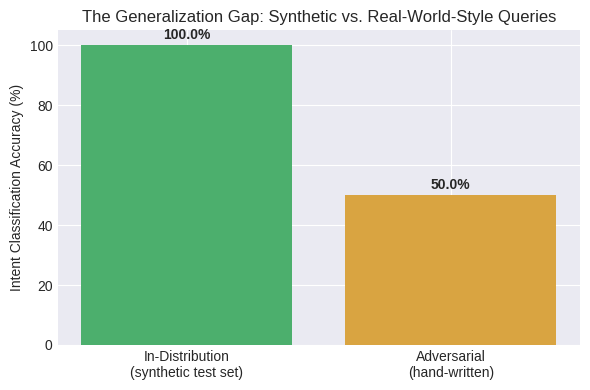


This 50 percentage-point gap is this project's most important
honest finding about the NLP component -- see EVALUATION_SUMMARY.md
and the paper's Discussion/Limitations section.


In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['In-Distribution\n(synthetic test set)', 'Adversarial\n(hand-written)'],
              [acc * 100, stress_acc * 100],
              color=['#4caf6d', '#d9a441'])
ax.set_ylabel('Intent Classification Accuracy (%)')
ax.set_ylim(0, 105)
ax.set_title('The Generalization Gap: Synthetic vs. Real-World-Style Queries')
for bar, val in zip(bars, [acc * 100, stress_acc * 100]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('nlp_generalization_gap.png', dpi=120)
plt.show()

print(f"\nThis {acc*100 - stress_acc*100:.0f} percentage-point gap is this project's most important")
print("honest finding about the NLP component -- see EVALUATION_SUMMARY.md")
print("and the paper's Discussion/Limitations section.")


## 10. Saving the Model

The trained pipeline (TF-IDF vectorizer + classifier bundled together) is
saved so it can be loaded directly by the production API
(`backend/nlp/nlp_pipeline.py`) without retraining.


In [11]:
MODEL_OUT = Path.cwd().parent / "backend" / "nlp" / "saved_models" / "intent_classifier.joblib"
MODEL_OUT.parent.mkdir(exist_ok=True, parents=True)
joblib.dump(pipeline, MODEL_OUT)
print(f"Model saved to: {MODEL_OUT}")


Model saved to: /home/claude/campus-dss/backend/nlp/saved_models/intent_classifier.joblib


## 11. Summary

| Evaluation | Accuracy |
|---|---|
| In-distribution (synthetic held-out test set) | See Section 5 output above |
| Adversarial (hand-written, real-world-style) | See Section 9 output above |

This model is one of two trained models in the Campus Spatial Decision
Support System (the other being the compatibility classifier in
`model_building.ipynb`). Together they power the `/query` endpoint: this
model determines *what* a question is asking, and the compatibility
classifier (via SHAP) explains *why* a given machine is or isn't compatible.
